# Travel Reimbursement Approval Agent

**AI Developer Candidate Assignment — Sameer Shaik**

An agentic workflow that reviews employee travel reimbursement claims against a written policy (Appendix A), decides **APPROVE / PARTIAL_APPROVE / REJECT / MANUAL_REVIEW**, and explains itself with policy citations, a full audit trail, and a results dashboard.

```
                     ┌────────────── deterministic tools ───────────────┐
 claim JSON ───────► │ lookup_policy · check_item_eligibility           │
                     │ check_receipts · check_limits · check_timeliness │
 Gemini 2.5 Flash ◄──┤ find_duplicates · check_approval_threshold       │
 (Vertex AI)      ──►└──────────────────────────────────────────────────┘
    function-calling loop — the model chooses which tools to call, and when
         │
         ▼  tool evidence + reasoning summary
  schema-enforced JSON decision  ──►  output validator (one retry on failure)
         │
         ▼
  cross-check vs deterministic rules engine — disagreement ⇒ MANUAL_REVIEW
         │
         ▼
  final results JSON · audit trail · dashboard (UI SS_1.png / UI SS_2.png)
```

**Design principle:** the LLM plans, orchestrates tools, and explains; every dollar of arithmetic and every policy check is a deterministic Python tool. Ambiguity is never forced into a decision — it is routed to Manual Review.

## README

### What this is
A single-notebook prototype of a Travel Reimbursement Approval Agent. It ingests the five sample claims from Appendix B as JSON, grounds itself in the Appendix A policy (every rule has a stable `POL-*` id), lets Gemini drive seven deterministic tools through a function-calling loop, and emits one validated, schema-constrained result object per claim.

### Setup

```bash
git clone https://github.com/sameersheikh22/travel-reimbursement-agent.git
cd travel-reimbursement-agent
python3 -m venv .venv && source .venv/bin/activate
pip install -U google-genai pandas matplotlib ipywidgets jupyter
jupyter notebook sameershaik.ipynb        # then: Run ▸ Run All Cells
```

The first code cell also `%pip`-installs the dependencies, so a plain **Run All** works in any Jupyter environment.

### Environment variables

| Variable | Required | Default | Purpose |
|---|---|---|---|
| `GOOGLE_API_KEY` | one auth option | — | Free-tier Gemini API key (aistudio.google.com). If set, it is used directly. |
| `GOOGLE_CLOUD_PROJECT` | other auth option | `vassarai-208611` | Vertex AI project, used with `gcloud auth application-default login`. |
| `GOOGLE_CLOUD_LOCATION` | no | `global` | Vertex AI location. |
| `GENAI_MODEL` | no | `gemini-2.5-flash` | Model id. |

**No credentials at all?** The notebook still runs top-to-bottom: it detects the missing LLM and falls back to the deterministic rules engine, marking each result as a fallback decision.

### How to run the demo
Run all cells. Section 6 shows the agent working through each claim with its audit trail; the **Dashboard** section renders the results UI (also saved as `UI SS_1.png` / `UI SS_2.png`) plus an interactive form to edit a claim and re-evaluate it; the **final cell prints the required JSON array** for all five claims.

### Key design choices (details in *Design Notes & Reasoning*)
- LLM orchestrates and explains; deterministic tools own all money math and policy checks.
- Direct `google-genai` SDK with an explicit ~30-line function-calling loop — no framework, fully inspectable.
- Two-phase decision: free tool-use investigation, then a `response_schema`-forced JSON commit.
- Reliability ladder: schema enum → output validator with one retry → amount reconciliation → deterministic cross-check (disagreement ⇒ Manual Review) → offline fallback.

In [1]:
# Dependencies — safe to re-run; no-ops when already installed.
%pip install -q google-genai pandas matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import datetime as dt
import json
import os
import re

import pandas as pd
from google import genai
from google.genai import types

PROJECT = os.environ.get("GOOGLE_CLOUD_PROJECT", "vassarai-208611")
LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "global")
MODEL_ID = os.environ.get("GENAI_MODEL", "gemini-2.5-flash")

# Prefer a plain Gemini API key when provided; otherwise Vertex AI via
# application-default credentials. If neither works, the notebook still runs
# using the deterministic rules engine (section 4) as a fallback.
try:
    if os.environ.get("GOOGLE_API_KEY"):
        client = genai.Client()
        backend = "Gemini API key"
    else:
        client = genai.Client(vertexai=True, project=PROJECT, location=LOCATION)
        backend = f"Vertex AI (project={PROJECT}, location={LOCATION})"
    client.models.generate_content(model=MODEL_ID, contents="ping")
    LLM_AVAILABLE = True
    print(f"LLM ready: {MODEL_ID} via {backend}")
except Exception as exc:
    client, LLM_AVAILABLE = None, False
    print(f"LLM unavailable ({type(exc).__name__}: {exc}) — falling back to the deterministic rules engine.")

LLM ready: gemini-2.5-flash via Vertex AI (project=vassarai-208611, location=global)


## 1 · Policy knowledge base (Appendix A)

The policy is stored as a rule dictionary keyed by its stable `POL-*` ids, plus a limits table and the approval matrix. The agent grounds itself by calling `lookup_policy` (a keyword retriever over this knowledge base) **before** deciding — at this scale (12 rules) keyword retrieval is a deliberate, honest stand-in for embedding-based RAG.

In [3]:
POLICY = {
    "POL-CAT-01": "Eligible categories — reimbursable with a documented business purpose: airfare (economy only, see POL-AIR-01), lodging (hotel room charges), meals (per-diem POL-PD-01), ground transport (taxi, rideshare, train, rental car, parking), conference/registration fees.",
    "POL-CAT-02": "Ineligible items — never reimbursable, deducted in full: alcohol and minibar; spa, gym and personal entertainment; in-room movies, personal shopping, gifts; traffic fines, penalties and late fees; any personal (non-business) expense.",
    "POL-PD-01": "Meals — maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.",
    "POL-PD-02": "Lodging — maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.",
    "POL-PD-03": "Ground transport — maximum $50 per day. Amounts above the cap are deducted.",
    "POL-AIR-01": "Airfare class — only economy class is reimbursable. Business/first-class fares are a policy exception and must be routed to Manual Review (not auto-deducted, because a pre-approval may exist).",
    "POL-RCT-01": "Receipt required above $25 — any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always require a receipt regardless of amount.",
    "POL-RCT-02": "Missing receipt handling — if a required receipt is missing, the item is not silently rejected; the claim is routed to Manual Review so the reviewer can request the receipt.",
    "POL-APR-01": "Auto-approve tier — total reimbursable <= $500 may be auto-approved by the agent when fully compliant.",
    "POL-APR-02": "Manager tier — total reimbursable > $500 and <= $2,000 is approvable when fully compliant.",
    "POL-APR-03": "Director tier — total reimbursable > $2,000 exceeds the agent's authority and must be routed to Manual Review (director approval), even if otherwise compliant.",
    "POL-TIME-01": "Submission window — claims must be submitted within 30 days of the expense date; late claims are routed to Manual Review.",
}

POLICY_TAGS = {
    "POL-CAT-01": {"eligible", "eligibility", "category", "categories", "airfare", "lodging", "meals", "transport", "taxi", "conference", "registration"},
    "POL-CAT-02": {"ineligible", "eligibility", "alcohol", "minibar", "spa", "gym", "entertainment", "movies", "shopping", "gifts", "fines", "penalties", "personal"},
    "POL-PD-01": {"meals", "meal", "food", "dinner", "per", "diem", "perdiem", "limit", "limits", "cap", "caps"},
    "POL-PD-02": {"lodging", "hotel", "night", "nightly", "per", "diem", "perdiem", "limit", "limits", "cap", "caps"},
    "POL-PD-03": {"ground", "transport", "taxi", "rideshare", "train", "rental", "parking", "limit", "limits", "cap", "caps"},
    "POL-AIR-01": {"airfare", "flight", "class", "economy", "business", "first"},
    "POL-RCT-01": {"receipt", "receipts", "documentation", "itemized", "docs"},
    "POL-RCT-02": {"receipt", "receipts", "missing", "documentation", "docs"},
    "POL-APR-01": {"approval", "approve", "threshold", "thresholds", "tier", "authority", "auto"},
    "POL-APR-02": {"approval", "approve", "threshold", "thresholds", "tier", "authority", "manager"},
    "POL-APR-03": {"approval", "approve", "threshold", "thresholds", "tier", "authority", "director", "review"},
    "POL-TIME-01": {"deadline", "submission", "submitted", "late", "window", "timeliness", "days"},
}

LIMITS = {
    "meals": {"cap_usd": 75, "per": "day", "policy_ref": "POL-PD-01"},
    "lodging": {"cap_usd": 200, "per": "night", "policy_ref": "POL-PD-02"},
    "ground_transport": {"cap_usd": 50, "per": "day", "policy_ref": "POL-PD-03"},
}

APPROVAL_MATRIX = [
    {"tier": "auto_approve", "min_exclusive": None, "max_inclusive": 500, "policy_ref": "POL-APR-01"},
    {"tier": "manager_approvable", "min_exclusive": 500, "max_inclusive": 2000, "policy_ref": "POL-APR-02"},
    {"tier": "director_manual_review", "min_exclusive": 2000, "max_inclusive": None, "policy_ref": "POL-APR-03"},
]

display(pd.DataFrame([{"policy_id": k, "rule": v} for k, v in POLICY.items()]).style.hide(axis="index"))
display(pd.DataFrame(LIMITS).T.rename_axis("category"))

policy_id,rule
POL-CAT-01,"Eligible categories — reimbursable with a documented business purpose: airfare (economy only, see POL-AIR-01), lodging (hotel room charges), meals (per-diem POL-PD-01), ground transport (taxi, rideshare, train, rental car, parking), conference/registration fees."
POL-CAT-02,"Ineligible items — never reimbursable, deducted in full: alcohol and minibar; spa, gym and personal entertainment; in-room movies, personal shopping, gifts; traffic fines, penalties and late fees; any personal (non-business) expense."
POL-PD-01,Meals — maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.
POL-PD-02,Lodging — maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.
POL-PD-03,Ground transport — maximum $50 per day. Amounts above the cap are deducted.
POL-AIR-01,"Airfare class — only economy class is reimbursable. Business/first-class fares are a policy exception and must be routed to Manual Review (not auto-deducted, because a pre-approval may exist)."
POL-RCT-01,"Receipt required above $25 — any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always require a receipt regardless of amount."
POL-RCT-02,"Missing receipt handling — if a required receipt is missing, the item is not silently rejected; the claim is routed to Manual Review so the reviewer can request the receipt."
POL-APR-01,Auto-approve tier — total reimbursable <= $500 may be auto-approved by the agent when fully compliant.
POL-APR-02,"Manager tier — total reimbursable > $500 and <= $2,000 is approvable when fully compliant."


,cap_usd,per,policy_ref
category,,,
meals,75,day,POL-PD-01
lodging,200,night,POL-PD-02
ground_transport,50,day,POL-PD-03


## 2 · Claim intake (Appendix B)

Claims are accepted as JSON (the format below also backs the interactive form in the Dashboard section — any claim shaped like this can be evaluated). `load_claims` validates the shape before anything touches the agent.

In [4]:
RAW_CLAIMS_JSON = """
[
  {
    "claim_id": "CLM-001",
    "employee": "A. Rivera",
    "purpose": "Attend 2-day industry conference (business)",
    "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20",
    "items": [
      {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": true},
      {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": true},
      {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": true},
      {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-002",
    "employee": "B. Osei",
    "purpose": "Weekend hotel stay",
    "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25",
    "items": [
      {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": true},
      {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-003",
    "employee": "C. Nakamura",
    "purpose": "Client site visit (business)",
    "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22",
    "items": [
      {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": true},
      {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": true},
      {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": true}
    ]
  },
  {
    "claim_id": "CLM-004",
    "employee": "D. Fischer",
    "purpose": "International vendor negotiation (business)",
    "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28",
    "items": [
      {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": true},
      {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": false}
    ]
  },
  {
    "claim_id": "CLM-005",
    "employee": "E. Haddad",
    "purpose": "Client dinner / business development",
    "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24",
    "items": [
      {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": false}
    ]
  }
]
"""

def load_claims(raw_json: str) -> list:
    """Claim intake: parse and validate claims from JSON."""
    claims = json.loads(raw_json)
    required = {"claim_id", "employee", "purpose", "trip_start", "trip_end", "submitted", "items"}
    item_required = {"category", "description", "amount", "receipt_attached"}
    for c in claims:
        missing = required - c.keys()
        if missing:
            raise ValueError(f"{c.get('claim_id', '?')}: missing fields {sorted(missing)}")
        for key in ("trip_start", "trip_end", "submitted"):
            dt.date.fromisoformat(c[key])  # raises if malformed
        if not c["items"]:
            raise ValueError(f"{c['claim_id']}: claim has no line items")
        for item in c["items"]:
            if item_required - item.keys():
                raise ValueError(f"{c['claim_id']}: item missing fields {sorted(item_required - item.keys())}")
            if float(item["amount"]) < 0:
                raise ValueError(f"{c['claim_id']}: negative amount")
    return claims

CLAIMS = load_claims(RAW_CLAIMS_JSON)
CLAIM_INDEX = {c["claim_id"]: c for c in CLAIMS}

flat = [
    {"claim_id": c["claim_id"], "employee": c["employee"], "trip": f"{c['trip_start']} → {c['trip_end']}",
     "submitted": c["submitted"], "category": i["category"], "description": i["description"],
     "amount_usd": i["amount"], "receipt": "yes" if i["receipt_attached"] else "NO"}
    for c in CLAIMS for i in c["items"]
]
display(pd.DataFrame(flat).style.hide(axis="index"))
print(f"{len(CLAIMS)} claims loaded, total claimed ${sum(i['amount'] for c in CLAIMS for i in c['items']):,.2f}")

claim_id,employee,trip,submitted,category,description,amount_usd,receipt
CLM-001,A. Rivera,2026-06-10 → 2026-06-12,2026-06-20,airfare,Round-trip economy airfare,420.000000,yes
CLM-001,A. Rivera,2026-06-10 → 2026-06-12,2026-06-20,lodging,"Hotel, 2 nights @ $180",360.000000,yes
CLM-001,A. Rivera,2026-06-10 → 2026-06-12,2026-06-20,meals,"Meals, 3 days @ ~$60/day",180.000000,yes
CLM-001,A. Rivera,2026-06-10 → 2026-06-12,2026-06-20,conference_fees,Conference registration,150.000000,yes
CLM-002,B. Osei,2026-06-14 → 2026-06-15,2026-06-25,spa,Hotel spa package,300.000000,yes
CLM-002,B. Osei,2026-06-14 → 2026-06-15,2026-06-25,minibar,In-room minibar,80.000000,yes
CLM-003,C. Nakamura,2026-06-08 → 2026-06-10,2026-06-22,airfare,Round-trip economy airfare,300.000000,yes
CLM-003,C. Nakamura,2026-06-08 → 2026-06-10,2026-06-22,lodging,"Hotel, 2 nights @ $250",500.000000,yes
CLM-003,C. Nakamura,2026-06-08 → 2026-06-10,2026-06-22,meals,"Meals, 2 days @ $70/day",140.000000,yes
CLM-004,D. Fischer,2026-06-16 → 2026-06-18,2026-06-28,airfare,Business-class international airfare,2400.000000,yes


5 claims loaded, total claimed $5,650.00


## 3 · Tools — deterministic checks the agent can call

Seven tools, all pure Python, all returning JSON. The agent (not hard-coded control flow) decides which to call and in what order:

| Tool | What it does | Policy |
|---|---|---|
| `lookup_policy` | Retrieves the policy rules relevant to a topic (context grounding). | all `POL-*` |
| `check_item_eligibility` | Classifies each line item eligible / ineligible / unknown. | POL-CAT-01/02 |
| `check_receipts` | Receipt-completeness check; lists items missing a required receipt. | POL-RCT-01/02 |
| `check_limits` | Per-diem/category caps from the trip dates; flags non-economy airfare. | POL-PD-01/02/03, POL-AIR-01 |
| `check_timeliness` | 30-day submission-window check. | POL-TIME-01 |
| `find_duplicates` | Duplicate detector within a claim and across claims. | — |
| `check_approval_threshold` | Maps the post-deduction reimbursable total to an approval tier. | POL-APR-01/02/03 |

An eighth function, `validate_result` (section 5), acts as the output validator on the agent's final JSON.

In [5]:
ELIGIBLE_CATEGORIES = {"airfare", "lodging", "meals", "ground_transport", "taxi", "rideshare",
                       "train", "rental_car", "parking", "conference_fees", "registration_fees"}
INELIGIBLE_CATEGORIES = {"spa", "minibar", "alcohol", "gym", "entertainment", "in_room_movies", "movies",
                         "personal", "personal_shopping", "shopping", "gifts", "fines", "traffic_fines",
                         "penalties", "late_fees"}
INELIGIBLE_KEYWORDS = ("alcohol", "minibar", "spa ", "spa,", "gym", "massage", "in-room movie",
                       "entertainment", "personal shopping", "gift", "traffic fine", "penalty", "late fee")
GROUND_TRANSPORT = {"ground_transport", "taxi", "rideshare", "train", "rental_car", "parking"}


def _get_claim(claim_id: str) -> dict:
    if claim_id not in CLAIM_INDEX:
        raise ValueError(f"Unknown claim_id: {claim_id}")
    return CLAIM_INDEX[claim_id]


def _trip_span(claim: dict) -> tuple:
    start = dt.date.fromisoformat(claim["trip_start"])
    end = dt.date.fromisoformat(claim["trip_end"])
    days = max((end - start).days, 0) + 1   # inclusive day count
    nights = max((end - start).days, 0)
    return days, nights


def lookup_policy(topic: str) -> dict:
    """Retrieve the policy rules relevant to a topic, e.g. 'meals per diem', 'receipts',
    'airfare class', 'approval thresholds', 'submission deadline', 'eligible categories'."""
    words = set(re.findall(r"[a-z]+", topic.lower()))
    hits = {pid: POLICY[pid] for pid, tags in POLICY_TAGS.items() if words & tags}
    return {"topic": topic, "rules": hits or POLICY}


def check_item_eligibility(claim_id: str) -> dict:
    """Classify each line item as eligible / ineligible / unknown per POL-CAT-01 and POL-CAT-02,
    and total the ineligible amount (ineligible items are deducted in full)."""
    claim = _get_claim(claim_id)
    items = []
    for idx, item in enumerate(claim["items"]):
        cat = item["category"].lower()
        desc = item.get("description", "").lower()
        if cat in INELIGIBLE_CATEGORIES or any(k in desc for k in INELIGIBLE_KEYWORDS):
            status, ref = "ineligible", "POL-CAT-02"
        elif cat in ELIGIBLE_CATEGORIES:
            status, ref = "eligible", "POL-CAT-01"
        else:
            status, ref = "unknown", "POL-CAT-01"
        items.append({"index": idx, "category": item["category"], "amount": item["amount"],
                      "status": status, "policy_ref": ref})
    return {"claim_id": claim_id, "items": items,
            "ineligible_total": round(sum(i["amount"] for i in items if i["status"] == "ineligible"), 2),
            "has_unknown_category": any(i["status"] == "unknown" for i in items)}


def check_receipts(claim_id: str) -> dict:
    """Receipt completeness per POL-RCT-01 (required above $25; always for airfare and lodging).
    Missing required receipts route the claim to Manual Review per POL-RCT-02."""
    claim = _get_claim(claim_id)
    missing = []
    for item in claim["items"]:
        required = item["amount"] > 25 or item["category"].lower() in ("airfare", "lodging")
        if required and not item.get("receipt_attached", False):
            missing.append(f"{item['category']} receipt (${item['amount']:.2f})")
    return {"claim_id": claim_id, "missing_receipts": missing,
            "requires_manual_review": bool(missing),
            "policy_refs": ["POL-RCT-01", "POL-RCT-02"] if missing else ["POL-RCT-01"]}


def check_limits(claim_id: str) -> dict:
    """Apply per-diem/category caps (POL-PD-01/02/03) using the trip dates, and flag non-economy
    airfare as a policy exception per POL-AIR-01 (not auto-deducted). Returns per-item allowed
    amounts and deductions plus the day/night counts derived from the dates."""
    claim = _get_claim(claim_id)
    days, nights = _trip_span(claim)
    items, refs = [], set()
    airfare_exception = False
    for idx, item in enumerate(claim["items"]):
        cat = item["category"].lower()
        amount = float(item["amount"])
        allowed, deducted, note = amount, 0.0, ""
        if cat == "meals":
            cap = LIMITS["meals"]["cap_usd"] * days
            refs.add("POL-PD-01")
            if amount > cap:
                allowed, deducted = cap, round(amount - cap, 2)
                note = f"exceeds ${LIMITS['meals']['cap_usd']}/day x {days} day(s) = ${cap:.2f} cap"
        elif cat == "lodging":
            cap = LIMITS["lodging"]["cap_usd"] * max(nights, 1)
            refs.add("POL-PD-02")
            if amount > cap:
                allowed, deducted = cap, round(amount - cap, 2)
                note = f"exceeds ${LIMITS['lodging']['cap_usd']}/night x {max(nights, 1)} night(s) from trip dates = ${cap:.2f} cap"
        elif cat in GROUND_TRANSPORT:
            cap = LIMITS["ground_transport"]["cap_usd"] * days
            refs.add("POL-PD-03")
            if amount > cap:
                allowed, deducted = cap, round(amount - cap, 2)
                note = f"exceeds ${LIMITS['ground_transport']['cap_usd']}/day x {days} day(s) = ${cap:.2f} cap"
        elif cat == "airfare":
            refs.add("POL-AIR-01")
            if any(k in item.get("description", "").lower() for k in ("business", "first")):
                airfare_exception = True
                note = "non-economy airfare — policy exception, route to Manual Review (POL-AIR-01); not auto-deducted because a pre-approval may exist"
        items.append({"index": idx, "category": item["category"], "amount": amount,
                      "allowed": round(allowed, 2), "deducted": round(deducted, 2), "note": note})
    return {"claim_id": claim_id, "trip_days": days, "trip_nights": nights, "items": items,
            "per_diem_deduction_total": round(sum(i["deducted"] for i in items), 2),
            "airfare_class_exception": airfare_exception, "policy_refs": sorted(refs)}


def check_timeliness(claim_id: str) -> dict:
    """Check the 30-day submission window (POL-TIME-01), measured from the last day of the trip."""
    claim = _get_claim(claim_id)
    gap = (dt.date.fromisoformat(claim["submitted"]) - dt.date.fromisoformat(claim["trip_end"])).days
    return {"claim_id": claim_id, "days_between_trip_end_and_submission": gap,
            "late": gap > 30, "requires_manual_review": gap > 30, "policy_ref": "POL-TIME-01"}


def find_duplicates(claim_id: str) -> dict:
    """Duplicate detector: repeated (category, amount) line items inside this claim, or the same
    employee claiming an identical (category, amount) item in another submitted claim."""
    claim = _get_claim(claim_id)
    duplicates, seen = [], {}
    for idx, item in enumerate(claim["items"]):
        key = (item["category"].lower(), round(float(item["amount"]), 2))
        if key in seen:
            duplicates.append({"type": "within_claim", "category": item["category"],
                               "amount": item["amount"], "item_indexes": [seen[key], idx]})
        seen[key] = idx
    for other in CLAIMS:
        if other["claim_id"] == claim_id or other["employee"] != claim["employee"]:
            continue
        for item in claim["items"]:
            for other_item in other["items"]:
                if (item["category"].lower() == other_item["category"].lower()
                        and abs(float(item["amount"]) - float(other_item["amount"])) < 0.01):
                    duplicates.append({"type": "cross_claim", "other_claim": other["claim_id"],
                                       "category": item["category"], "amount": item["amount"]})
    return {"claim_id": claim_id, "duplicates": duplicates, "requires_manual_review": bool(duplicates)}


def check_approval_threshold(claim_id: str, reimbursable_total: float) -> dict:
    """Map the post-deduction reimbursable total to an approval tier (POL-APR-01/02/03).
    Totals over $2,000 exceed the agent's authority and require Manual Review."""
    total = round(float(reimbursable_total), 2)
    if total <= 500:
        tier, ref = "auto_approve", "POL-APR-01"
    elif total <= 2000:
        tier, ref = "manager_approvable", "POL-APR-02"
    else:
        tier, ref = "director_manual_review", "POL-APR-03"
    return {"claim_id": claim_id, "reimbursable_total": total, "tier": tier,
            "requires_manual_review": tier == "director_manual_review", "policy_ref": ref}


TOOL_REGISTRY = {fn.__name__: fn for fn in (
    lookup_policy, check_item_eligibility, check_receipts, check_limits,
    check_timeliness, find_duplicates, check_approval_threshold)}

_STR = lambda desc: types.Schema(type=types.Type.STRING, description=desc)
_CLAIM_ID = _STR("Claim id, e.g. CLM-001")

def _decl(fn, params, required):
    return types.FunctionDeclaration(
        name=fn.__name__, description=fn.__doc__,
        parameters=types.Schema(type=types.Type.OBJECT, properties=params, required=required))

FUNCTION_DECLARATIONS = [
    _decl(lookup_policy, {"topic": _STR("Topic keywords, e.g. 'meals per diem', 'receipts', 'airfare class', 'approval thresholds', 'submission deadline'")}, ["topic"]),
    _decl(check_item_eligibility, {"claim_id": _CLAIM_ID}, ["claim_id"]),
    _decl(check_receipts, {"claim_id": _CLAIM_ID}, ["claim_id"]),
    _decl(check_limits, {"claim_id": _CLAIM_ID}, ["claim_id"]),
    _decl(check_timeliness, {"claim_id": _CLAIM_ID}, ["claim_id"]),
    _decl(find_duplicates, {"claim_id": _CLAIM_ID}, ["claim_id"]),
    _decl(check_approval_threshold, {
        "claim_id": _CLAIM_ID,
        "reimbursable_total": types.Schema(type=types.Type.NUMBER, description="Claimed total minus ineligible items and per-diem deductions"),
    }, ["claim_id", "reimbursable_total"]),
]
AGENT_TOOLS = [types.Tool(function_declarations=FUNCTION_DECLARATIONS)]

# Smoke test: the limits checker on CLM-003 should deduct $100 of lodging (2 nights @ $250 vs $200 cap).
print(json.dumps(check_limits("CLM-003"), indent=2))

{
  "claim_id": "CLM-003",
  "trip_days": 3,
  "trip_nights": 2,
  "items": [
    {
      "index": 0,
      "category": "airfare",
      "amount": 300.0,
      "allowed": 300.0,
      "deducted": 0.0,
      "note": ""
    },
    {
      "index": 1,
      "category": "lodging",
      "amount": 500.0,
      "allowed": 400,
      "deducted": 100.0,
      "note": "exceeds $200/night x 2 night(s) from trip dates = $400.00 cap"
    },
    {
      "index": 2,
      "category": "meals",
      "amount": 140.0,
      "allowed": 140.0,
      "deducted": 0.0,
      "note": ""
    }
  ],
  "per_diem_deduction_total": 100.0,
  "airfare_class_exception": false,
  "policy_refs": [
    "POL-AIR-01",
    "POL-PD-01",
    "POL-PD-02"
  ]
}


## 4 · Deterministic rules engine — cross-check & offline fallback

The same tools, combined with fixed logic instead of an LLM. It exists for two reasons:

1. **Cross-check:** if the agent's decision disagrees with the engine, the claim is routed to `MANUAL_REVIEW` — an LLM should not out-vote deterministic policy math silently, and a human seeing both opinions is the safe outcome.
2. **Fallback:** if no LLM credentials are available (or the agent's output fails validation twice), the notebook still produces sound, policy-grounded decisions end-to-end.

In [6]:
DECISIONS = ("APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW")
FINAL_FIELDS = ["claim_id", "decision", "approved_amount", "deducted_amount",
                "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"]
ENGINE_TOOLS = ["check_item_eligibility", "check_receipts", "check_limits",
                "check_timeliness", "find_duplicates", "check_approval_threshold"]


def rules_engine_decision(claim: dict) -> dict:
    """Deterministic combination of the tool results (no LLM)."""
    cid = claim["claim_id"]
    CLAIM_INDEX[cid] = claim
    total = round(sum(i["amount"] for i in claim["items"]), 2)
    eligibility = check_item_eligibility(cid)
    receipts = check_receipts(cid)
    limits = check_limits(cid)
    timeliness = check_timeliness(cid)
    duplicates = find_duplicates(cid)
    reimbursable = round(total - eligibility["ineligible_total"] - limits["per_diem_deduction_total"], 2)
    threshold = check_approval_threshold(cid, reimbursable)

    refs = ({i["policy_ref"] for i in eligibility["items"]}
            | set(receipts["policy_refs"]) | set(limits["policy_refs"]) | {threshold["policy_ref"]})
    reasons = []
    if receipts["missing_receipts"]:
        reasons.append(f"missing required receipt(s): {', '.join(receipts['missing_receipts'])} (POL-RCT-02)")
    if limits["airfare_class_exception"]:
        reasons.append("non-economy airfare policy exception (POL-AIR-01)")
    if timeliness["late"]:
        reasons.append(f"submitted {timeliness['days_between_trip_end_and_submission']} days after trip end (POL-TIME-01)")
        refs.add("POL-TIME-01")
    if duplicates["duplicates"]:
        reasons.append(f"{len(duplicates['duplicates'])} potential duplicate line item(s)")
    if eligibility["has_unknown_category"]:
        reasons.append("unrecognized expense category")
    if threshold["requires_manual_review"]:
        reasons.append(f"reimbursable total ${reimbursable:.2f} exceeds the $2,000 agent authority (POL-APR-03)")

    deductions = round(eligibility["ineligible_total"] + limits["per_diem_deduction_total"], 2)
    if reasons:
        decision, approved, deducted, confidence = "MANUAL_REVIEW", 0.0, 0.0, 0.6
        explanation = "Routed to Manual Review: " + "; ".join(reasons) + ". Amounts are left to the human reviewer."
    elif reimbursable <= 0:
        decision, approved, deducted, confidence = "REJECT", 0.0, total, 0.9
        explanation = (f"All claimed items are ineligible under POL-CAT-02 "
                       f"(${eligibility['ineligible_total']:.2f} deducted in full); nothing is reimbursable.")
    elif deductions > 0:
        decision, approved, deducted, confidence = "PARTIAL_APPROVE", reimbursable, deductions, 0.85
        explanation = (f"Valid business claim; ${deductions:.2f} deducted "
                       f"(${limits['per_diem_deduction_total']:.2f} over per-diem caps, "
                       f"${eligibility['ineligible_total']:.2f} ineligible); ${reimbursable:.2f} reimbursed "
                       f"within the {threshold['tier']} tier.")
    else:
        decision, approved, deducted, confidence = "APPROVE", total, 0.0, 0.95
        explanation = (f"All items eligible with receipts attached and within per-diem caps; "
                       f"total ${total:.2f} falls in the {threshold['tier']} tier ({threshold['policy_ref']}).")

    return {"claim_id": cid, "decision": decision,
            "approved_amount": round(approved, 2), "deducted_amount": round(deducted, 2),
            "missing_docs": receipts["missing_receipts"], "policy_refs": sorted(refs),
            "confidence": confidence, "explanation": explanation, "tools_used": list(ENGINE_TOOLS)}


display(pd.DataFrame([
    {k: rules_engine_decision(c)[k] for k in ("claim_id", "decision", "approved_amount", "deducted_amount", "confidence")}
    for c in CLAIMS
]).style.hide(axis="index"))

claim_id,decision,approved_amount,deducted_amount,confidence
CLM-001,APPROVE,1110.000000,0.000000,0.950000
CLM-002,REJECT,0.000000,380.000000,0.900000
CLM-003,PARTIAL_APPROVE,840.000000,100.000000,0.850000
CLM-004,MANUAL_REVIEW,0.000000,0.000000,0.600000
CLM-005,MANUAL_REVIEW,0.000000,0.000000,0.600000


## 5 · The agent — GenAI workflow

Two phases per claim, then a reliability ladder:

1. **Investigate (agentic loop):** the model receives the claim JSON and the system prompt, then *chooses* which tools to call. We execute each call, record it in the audit trail, feed results back, and repeat until it stops requesting tools. The model decides ordering and when it has enough evidence — including handling missing/conflicting information (e.g. a description that contradicts the trip dates).
2. **Commit (structured output):** a second call converts claim + tool evidence + the agent's own analysis into the exact output contract, enforced by `response_schema` with a decision enum — the model cannot emit a malformed decision.
3. **Validate & reconcile:** `validate_result` checks field presence, enum membership, amount consistency (`approved + deducted = claimed total`, Manual Review ⇒ both 0). One retry with the validation errors; then fallback to the rules engine. Amounts are reconciled against the deterministic engine, `tools_used` is taken from the *actual* audit trail (never self-reported), and a decision disagreement with the engine routes the claim to Manual Review.

In [7]:
SYSTEM_PROMPT = """You are a corporate Travel Reimbursement Approval Agent.

You are given one claim as JSON. Decide one of: APPROVE, PARTIAL_APPROVE, REJECT, MANUAL_REVIEW.

Work method — ground every decision in tools, never in memory:
1. Call lookup_policy for the topics this claim touches (eligibility, receipts, per-diem caps, airfare class, approval thresholds, submission deadline).
2. Run the deterministic checks: check_item_eligibility, check_receipts, check_limits, check_timeliness, find_duplicates.
3. Compute reimbursable total = claimed total - ineligible items - per-diem deductions, then call check_approval_threshold with it.
4. Combine the evidence:
   - Only ineligible items and nothing reimbursable -> REJECT.
   - Valid claim but amounts over per-diem caps (or a mix with some ineligible items and a payable remainder) -> PARTIAL_APPROVE: reimburse up to the caps, deduct the excess.
   - Fully compliant, receipts complete, within an approvable tier -> APPROVE.
   - Missing required receipts, non-economy airfare, late submission, duplicates, reimbursable total > $2,000, unknown categories, or conflicting information (e.g. description contradicts the trip dates) -> MANUAL_REVIEW. Prefer MANUAL_REVIEW over forcing a decision.
5. Output conventions: for MANUAL_REVIEW, approved_amount and deducted_amount are both 0.00 (a human decides the amounts); otherwise approved_amount + deducted_amount must equal the claimed total. List missing documents in missing_docs. Cite every policy id (POL-*) you relied on in policy_refs. confidence is your 0-1 belief that a human reviewer would reach the same decision.

When you have enough evidence, stop calling tools and reply with a concise summary of your reasoning and recommended decision."""

RESULT_SCHEMA = types.Schema(
    type=types.Type.OBJECT,
    properties={
        "claim_id": types.Schema(type=types.Type.STRING),
        "decision": types.Schema(type=types.Type.STRING, enum=list(DECISIONS)),
        "approved_amount": types.Schema(type=types.Type.NUMBER),
        "deducted_amount": types.Schema(type=types.Type.NUMBER),
        "missing_docs": types.Schema(type=types.Type.ARRAY, items=types.Schema(type=types.Type.STRING)),
        "policy_refs": types.Schema(type=types.Type.ARRAY, items=types.Schema(type=types.Type.STRING)),
        "confidence": types.Schema(type=types.Type.NUMBER),
        "explanation": types.Schema(type=types.Type.STRING),
        "tools_used": types.Schema(type=types.Type.ARRAY, items=types.Schema(type=types.Type.STRING)),
    },
    required=FINAL_FIELDS,
)


def run_agent(claim: dict, max_steps: int = 8) -> tuple:
    """Phase 1 — manual function-calling loop. The model chooses the tools; every call is audited."""
    CLAIM_INDEX[claim["claim_id"]] = claim
    audit = []
    config = types.GenerateContentConfig(system_instruction=SYSTEM_PROMPT, tools=AGENT_TOOLS, temperature=0.0)
    contents = [types.Content(role="user", parts=[types.Part.from_text(
        text="Evaluate this reimbursement claim:\n" + json.dumps(claim, indent=2))])]
    for step in range(1, max_steps + 1):
        response = client.models.generate_content(model=MODEL_ID, contents=contents, config=config)
        calls = response.function_calls or []
        if not calls:
            return (response.text or ""), audit
        contents.append(response.candidates[0].content)
        parts = []
        for call in calls:
            args = dict(call.args or {})
            try:
                result = TOOL_REGISTRY[call.name](**args)
            except Exception as exc:
                result = {"error": f"{type(exc).__name__}: {exc}"}
            audit.append({"step": step, "tool": call.name, "args": args, "result": result})
            parts.append(types.Part.from_function_response(name=call.name, response={"result": result}))
        contents.append(types.Content(role="user", parts=parts))
    return "Tool budget exhausted before a final summary.", audit


def structured_decision(claim: dict, agent_summary: str, audit: list, problems: list = None) -> dict:
    """Phase 2 — schema-enforced JSON commit from claim + tool evidence + agent analysis."""
    evidence = [{"tool": a["tool"], "args": a["args"], "result": a["result"]} for a in audit]
    prompt = ("Produce the final structured decision object for this claim.\n\n"
              f"CLAIM:\n{json.dumps(claim, indent=2)}\n\n"
              f"TOOL EVIDENCE (ground truth for all arithmetic):\n{json.dumps(evidence, indent=2)}\n\n"
              f"AGENT ANALYSIS:\n{agent_summary}\n")
    if problems:
        prompt += "\nYour previous attempt was invalid: " + "; ".join(problems) + ". Fix exactly these issues."
    response = client.models.generate_content(
        model=MODEL_ID, contents=prompt,
        config=types.GenerateContentConfig(response_mime_type="application/json",
                                           response_schema=RESULT_SCHEMA, temperature=0.0))
    return json.loads(response.text)


def validate_result(result: dict, claim: dict) -> list:
    """Output validator: field presence, enum membership, amount consistency."""
    problems = [f"missing field {k}" for k in FINAL_FIELDS if k not in result]
    if problems:
        return problems
    total = round(sum(i["amount"] for i in claim["items"]), 2)
    if result["claim_id"] != claim["claim_id"]:
        problems.append("claim_id mismatch")
    if result["decision"] not in DECISIONS:
        problems.append(f"decision must be one of {DECISIONS}")
    if not 0 <= float(result["confidence"]) <= 1:
        problems.append("confidence must be between 0 and 1")
    approved, deducted = float(result["approved_amount"]), float(result["deducted_amount"])
    if approved < 0 or deducted < 0:
        problems.append("amounts must be >= 0")
    elif result["decision"] == "MANUAL_REVIEW":
        if approved != 0 or deducted != 0:
            problems.append("MANUAL_REVIEW requires approved_amount = deducted_amount = 0 (human decides)")
    elif abs((approved + deducted) - total) > 0.01:
        problems.append(f"approved_amount + deducted_amount must equal the claimed total ${total:.2f}")
    return problems


def evaluate_claim(claim: dict) -> tuple:
    """Full pipeline for one claim -> (result dict, audit trail)."""
    engine = rules_engine_decision(claim)
    if not LLM_AVAILABLE:
        result = dict(engine)
        result["explanation"] = "[deterministic fallback — no LLM credentials] " + result["explanation"]
        result["confidence"] = min(result["confidence"], 0.7)
        return result, []

    summary, audit = run_agent(claim)
    try:
        result = structured_decision(claim, summary, audit)
        problems = validate_result(result, claim)
        if problems:  # one retry, telling the model exactly what was wrong
            result = structured_decision(claim, summary, audit, problems)
            problems = validate_result(result, claim)
        if problems:
            raise ValueError("; ".join(problems))
    except Exception as exc:
        result = dict(engine)
        result["confidence"] = min(result["confidence"], 0.5)
        result["explanation"] += f" [fallback: agent output invalid after retry — {exc}]"
        return result, audit

    # tools_used comes from the real audit trail, never self-reported
    result["tools_used"] = list(dict.fromkeys(a["tool"] for a in audit))
    # keep only known policy ids
    result["policy_refs"] = sorted({p for p in result["policy_refs"] if p in POLICY})
    # reliability ladder: reconcile with the deterministic engine
    if result["decision"] != engine["decision"]:
        agent_said = result["decision"]
        result["decision"], result["approved_amount"], result["deducted_amount"] = "MANUAL_REVIEW", 0.0, 0.0
        result["confidence"] = min(float(result["confidence"]), 0.5)
        result["explanation"] += (f" [cross-check: agent recommended {agent_said} but the deterministic rules "
                                  f"engine computed {engine['decision']} — disagreement routed to Manual Review]")
    elif (abs(float(result["approved_amount"]) - engine["approved_amount"]) > 1.0
          or abs(float(result["deducted_amount"]) - engine["deducted_amount"]) > 1.0):
        result["approved_amount"], result["deducted_amount"] = engine["approved_amount"], engine["deducted_amount"]
        result["explanation"] += " [amounts reconciled to the deterministic per-diem math]"
    result["approved_amount"] = round(float(result["approved_amount"]), 2)
    result["deducted_amount"] = round(float(result["deducted_amount"]), 2)
    result["confidence"] = round(float(result["confidence"]), 2)
    return result, audit


print("Agent pipeline ready.")

Agent pipeline ready.


## 6 · Run the agent on all five claims

Each claim prints its audit trail — the tools the *model* chose to call, in order, with the key evidence each returned — followed by the validated decision. (With no LLM credentials this section transparently uses the rules-engine fallback.)

In [8]:
def _brief(tool: str, result: dict) -> str:
    if "error" in result:
        return "ERROR " + result["error"]
    if tool == "lookup_policy":
        return "rules: " + ", ".join(result["rules"])
    keep = ("ineligible_total", "has_unknown_category", "missing_receipts", "per_diem_deduction_total",
            "airfare_class_exception", "trip_days", "trip_nights", "late",
            "days_between_trip_end_and_submission", "duplicates", "reimbursable_total", "tier")
    parts = [f"{k}={result[k]}" for k in keep if k in result and result[k] not in ([], False, 0, 0.0)]
    return ", ".join(parts) or "no issues found"


results, audits = [], {}
for claim in CLAIMS:
    claimed_total = sum(i["amount"] for i in claim["items"])
    print("=" * 100)
    print(f"{claim['claim_id']} — {claim['purpose']}  (claimed ${claimed_total:,.2f})")
    result, audit = evaluate_claim(claim)
    results.append(result)
    audits[claim["claim_id"]] = audit
    for entry in audit:
        arg = entry["args"].get("topic") or entry["args"].get("claim_id", "")
        extra = f", {entry['args']['reimbursable_total']}" if "reimbursable_total" in entry["args"] else ""
        print(f"   step {entry['step']}  {entry['tool']}({arg!r}{extra})  ->  {_brief(entry['tool'], entry['result'])}")
    print(f"   DECISION: {result['decision']}   approved ${result['approved_amount']:,.2f} · "
          f"deducted ${result['deducted_amount']:,.2f} · confidence {result['confidence']:.2f}")
    print(f"   policy_refs: {', '.join(result['policy_refs'])}")
    if result["missing_docs"]:
        print(f"   missing_docs: {result['missing_docs']}")
    print(f"   {result['explanation']}")

print("=" * 100)
display(pd.DataFrame([{k: r[k] for k in ("claim_id", "decision", "approved_amount",
                                          "deducted_amount", "confidence")} for r in results])
        .style.hide(axis="index"))

CLM-001 — Attend 2-day industry conference (business)  (claimed $1,110.00)


   step 1  lookup_policy('eligible categories')  ->  rules: POL-CAT-01
   step 1  lookup_policy('receipts')  ->  rules: POL-RCT-01, POL-RCT-02
   step 1  lookup_policy('meals per diem')  ->  rules: POL-CAT-01, POL-PD-01, POL-PD-02
   step 1  lookup_policy('lodging per diem')  ->  rules: POL-CAT-01, POL-PD-01, POL-PD-02
   step 1  lookup_policy('airfare class')  ->  rules: POL-CAT-01, POL-AIR-01
   step 1  lookup_policy('approval thresholds')  ->  rules: POL-APR-01, POL-APR-02, POL-APR-03
   step 1  lookup_policy('submission deadline')  ->  rules: POL-TIME-01
   step 2  check_item_eligibility('CLM-001')  ->  no issues found
   step 2  check_receipts('CLM-001')  ->  no issues found
   step 2  check_limits('CLM-001')  ->  trip_days=3, trip_nights=2
   step 2  check_timeliness('CLM-001')  ->  days_between_trip_end_and_submission=8
   step 2  find_duplicates('CLM-001')  ->  no issues found
   step 3  check_approval_threshold('CLM-001', 1110)  ->  reimbursable_total=1110.0, tier=manager_appr

   step 1  lookup_policy('eligible categories')  ->  rules: POL-CAT-01
   step 1  lookup_policy('receipts')  ->  rules: POL-RCT-01, POL-RCT-02
   step 1  lookup_policy('per-diem caps')  ->  rules: POL-PD-01, POL-PD-02, POL-PD-03
   step 1  lookup_policy('approval thresholds')  ->  rules: POL-APR-01, POL-APR-02, POL-APR-03
   step 1  lookup_policy('submission deadline')  ->  rules: POL-TIME-01
   step 1  check_item_eligibility('CLM-002')  ->  ineligible_total=380.0
   step 1  check_receipts('CLM-002')  ->  no issues found
   step 1  check_limits('CLM-002')  ->  trip_days=2, trip_nights=1
   step 1  check_timeliness('CLM-002')  ->  days_between_trip_end_and_submission=10
   step 1  find_duplicates('CLM-002')  ->  no issues found
   step 2  check_approval_threshold('CLM-002', 0)  ->  tier=auto_approve
   DECISION: REJECT   approved $0.00 · deducted $380.00 · confidence 1.00
   policy_refs: POL-APR-01, POL-CAT-02
   The claim is rejected because both the spa package and minibar charges are

   step 1  lookup_policy('eligibility')  ->  rules: POL-CAT-01, POL-CAT-02
   step 1  lookup_policy('receipts')  ->  rules: POL-RCT-01, POL-RCT-02
   step 1  lookup_policy('per-diem caps')  ->  rules: POL-PD-01, POL-PD-02, POL-PD-03
   step 1  lookup_policy('airfare class')  ->  rules: POL-CAT-01, POL-AIR-01
   step 1  lookup_policy('approval thresholds')  ->  rules: POL-APR-01, POL-APR-02, POL-APR-03
   step 1  lookup_policy('submission deadline')  ->  rules: POL-TIME-01
   step 2  check_item_eligibility('CLM-003')  ->  no issues found
   step 2  check_receipts('CLM-003')  ->  no issues found
   step 2  check_limits('CLM-003')  ->  per_diem_deduction_total=100.0, trip_days=3, trip_nights=2
   step 2  check_timeliness('CLM-003')  ->  days_between_trip_end_and_submission=12
   step 2  find_duplicates('CLM-003')  ->  no issues found
   step 3  check_approval_threshold('CLM-003', 840)  ->  reimbursable_total=840.0, tier=manager_approvable
   DECISION: PARTIAL_APPROVE   approved $840.00 · 

   step 1  lookup_policy('eligible categories')  ->  rules: POL-CAT-01
   step 1  lookup_policy('receipts')  ->  rules: POL-RCT-01, POL-RCT-02
   step 1  lookup_policy('lodging per diem')  ->  rules: POL-CAT-01, POL-PD-01, POL-PD-02
   step 1  lookup_policy('airfare class')  ->  rules: POL-CAT-01, POL-AIR-01
   step 1  lookup_policy('approval thresholds')  ->  rules: POL-APR-01, POL-APR-02, POL-APR-03
   step 1  lookup_policy('submission deadline')  ->  rules: POL-TIME-01
   step 1  check_item_eligibility('CLM-004')  ->  no issues found
   step 1  check_receipts('CLM-004')  ->  missing_receipts=['lodging receipt ($600.00)']
   step 1  check_limits('CLM-004')  ->  per_diem_deduction_total=200.0, airfare_class_exception=True, trip_days=3, trip_nights=2
   step 1  check_timeliness('CLM-004')  ->  days_between_trip_end_and_submission=10
   step 1  find_duplicates('CLM-004')  ->  no issues found
   DECISION: MANUAL_REVIEW   approved $0.00 · deducted $0.00 · confidence 0.95
   policy_refs: P

   step 1  lookup_policy('meals per diem')  ->  rules: POL-CAT-01, POL-PD-01, POL-PD-02
   step 1  lookup_policy('receipts')  ->  rules: POL-RCT-01, POL-RCT-02
   step 1  lookup_policy('eligible categories')  ->  rules: POL-CAT-01
   step 1  lookup_policy('approval thresholds')  ->  rules: POL-APR-01, POL-APR-02, POL-APR-03
   step 1  lookup_policy('submission deadline')  ->  rules: POL-TIME-01
   step 2  check_item_eligibility('CLM-005')  ->  no issues found
   step 3  check_receipts('CLM-005')  ->  missing_receipts=['meals receipt ($220.00)']
   step 4  check_limits('CLM-005')  ->  per_diem_deduction_total=145.0, trip_days=1
   step 5  check_timeliness('CLM-005')  ->  days_between_trip_end_and_submission=13
   step 6  find_duplicates('CLM-005')  ->  no issues found
   step 7  check_approval_threshold('CLM-005', 75)  ->  reimbursable_total=75.0, tier=auto_approve
   DECISION: MANUAL_REVIEW   approved $0.00 · deducted $0.00 · confidence 0.95
   policy_refs: POL-APR-01, POL-CAT-01, POL-

claim_id,decision,approved_amount,deducted_amount,confidence
CLM-001,APPROVE,1110.000000,0.000000,1.000000
CLM-002,REJECT,0.000000,380.000000,1.000000
CLM-003,PARTIAL_APPROVE,840.000000,100.000000,1.000000
CLM-004,MANUAL_REVIEW,0.000000,0.000000,0.950000
CLM-005,MANUAL_REVIEW,0.000000,0.000000,0.950000


## 7 · Evaluation — expected outcomes vs agent vs rules engine

A small golden set derived by reading the policy by hand. The agent must match it, and the agent and the deterministic engine must agree (by construction, a disagreement would already have been routed to Manual Review).

In [9]:
EXPECTED = {
    "CLM-001": "APPROVE",          # fully compliant, $1,110 in the manager tier
    "CLM-002": "REJECT",           # spa + minibar are POL-CAT-02, nothing reimbursable
    "CLM-003": "PARTIAL_APPROVE",  # lodging $100 over the $200/night cap
    "CLM-004": "MANUAL_REVIEW",    # business-class airfare + missing lodging receipt + > $2,000
    "CLM-005": "MANUAL_REVIEW",    # $220 meal with no receipt (required above $25)
}

rows = []
for result in results:
    engine = rules_engine_decision(CLAIM_INDEX[result["claim_id"]])
    rows.append({
        "claim_id": result["claim_id"],
        "expected": EXPECTED[result["claim_id"]],
        "agent": result["decision"],
        "rules_engine": engine["decision"],
        "approved_usd": result["approved_amount"],
        "deducted_usd": result["deducted_amount"],
        "confidence": result["confidence"],
        "status": "PASS" if result["decision"] == EXPECTED[result["claim_id"]] else "FAIL",
    })
eval_df = pd.DataFrame(rows)
display(eval_df.style.hide(axis="index").apply(
    lambda s: ["color: #0ca30c; font-weight: bold" if v == "PASS" else "color: #d03b3b; font-weight: bold"
               for v in s] if s.name == "status" else [""] * len(s)))

passed = int((eval_df["status"] == "PASS").sum())
print(f"{passed}/{len(eval_df)} test cases pass."
      + ("" if passed == len(eval_df) else "  <-- investigate the FAIL rows above"))

claim_id,expected,agent,rules_engine,approved_usd,deducted_usd,confidence,status
CLM-001,APPROVE,APPROVE,APPROVE,1110.000000,0.000000,1.000000,PASS
CLM-002,REJECT,REJECT,REJECT,0.000000,380.000000,1.000000,PASS
CLM-003,PARTIAL_APPROVE,PARTIAL_APPROVE,PARTIAL_APPROVE,840.000000,100.000000,1.000000,PASS
CLM-004,MANUAL_REVIEW,MANUAL_REVIEW,MANUAL_REVIEW,0.000000,0.000000,0.950000,PASS
CLM-005,MANUAL_REVIEW,MANUAL_REVIEW,MANUAL_REVIEW,0.000000,0.000000,0.950000,PASS


5/5 test cases pass.


## Dashboard

A data-driven summary of the actual claim outcomes (saved next to the notebook as `UI SS_1.png` and `UI SS_2.png`), followed by an **interactive form**: pick or edit any claim as JSON and re-run the agent on it — this is the interface for interacting with the notebook's pipeline.

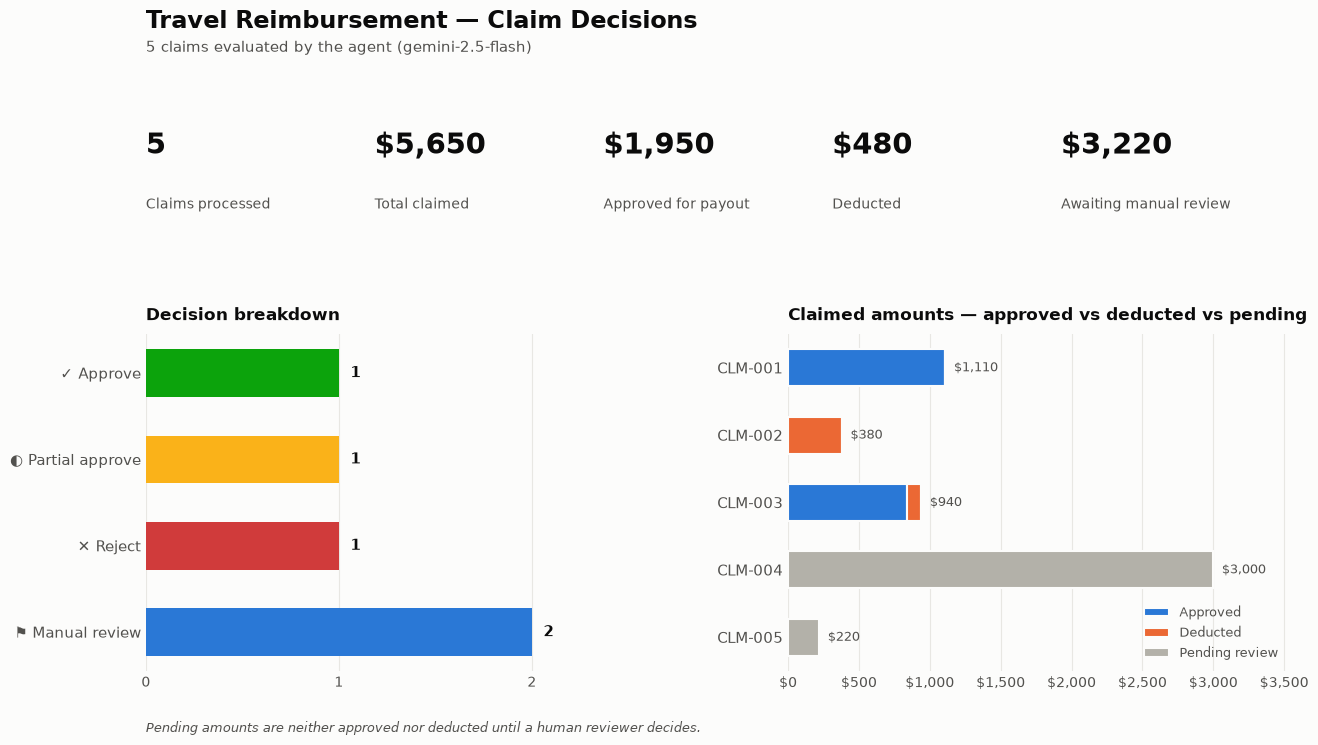

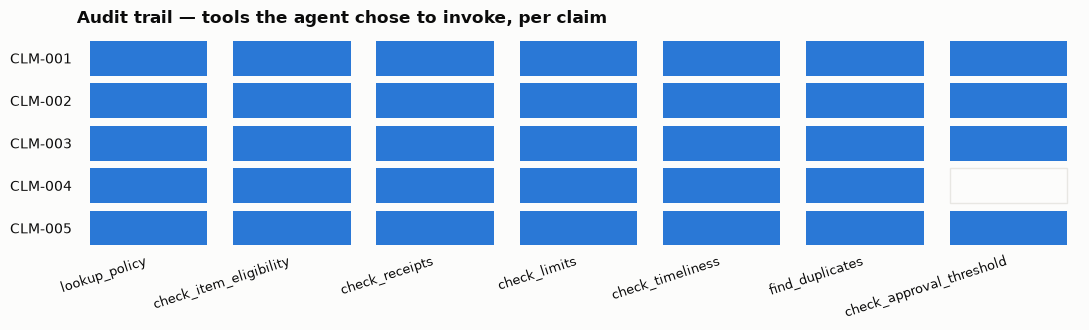

Saved: UI SS_1.png, UI SS_2.png


In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e8e7e3"
DECISION_STYLE = {  # status colors — icon + label so color never carries meaning alone
    "APPROVE": ("#0ca30c", "✓ Approve"),
    "PARTIAL_APPROVE": ("#fab219", "◐ Partial approve"),
    "REJECT": ("#d03b3b", "✕ Reject"),
    "MANUAL_REVIEW": ("#2a78d6", "⚑ Manual review"),
}
C_APPROVED, C_DEDUCTED, C_PENDING = "#2a78d6", "#eb6834", "#b3b1a9"

dash = pd.DataFrame(results)
dash["claimed"] = [round(sum(i["amount"] for i in CLAIM_INDEX[cid]["items"]), 2) for cid in dash["claim_id"]]
dash["pending"] = [row["claimed"] if row["decision"] == "MANUAL_REVIEW" else 0.0 for _, row in dash.iterrows()]

fig = plt.figure(figsize=(13, 7.6), facecolor=SURFACE)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2.7], hspace=0.5, wspace=0.28,
                      left=0.09, right=0.97, top=0.86, bottom=0.1)
fig.suptitle("Travel Reimbursement — Claim Decisions", x=0.09, y=0.97, ha="left",
             fontsize=17, fontweight="bold", color=INK)
fig.text(0.09, 0.915, f"{len(dash)} claims evaluated by the agent ({MODEL_ID if LLM_AVAILABLE else 'rules-engine fallback'})",
         fontsize=10.5, color=INK2)

# ── stat tiles ────────────────────────────────────────────────────────────────
tiles_ax = fig.add_subplot(gs[0, :])
tiles_ax.axis("off")
tiles = [
    ("Claims processed", f"{len(dash)}"),
    ("Total claimed", f"${dash['claimed'].sum():,.0f}"),
    ("Approved for payout", f"${dash['approved_amount'].sum():,.0f}"),
    ("Deducted", f"${dash['deducted_amount'].sum():,.0f}"),
    ("Awaiting manual review", f"${dash['pending'].sum():,.0f}"),
]
for i, (label, value) in enumerate(tiles):
    x = i / len(tiles)
    tiles_ax.text(x, 0.52, value, fontsize=21, fontweight="bold", color=INK, transform=tiles_ax.transAxes)
    tiles_ax.text(x, 0.08, label, fontsize=10, color=INK2, transform=tiles_ax.transAxes)

# ── decision breakdown ────────────────────────────────────────────────────────
ax_left = fig.add_subplot(gs[1, 0], facecolor=SURFACE)
order = [d for d in ("APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW")]
counts = dash["decision"].value_counts().reindex(order).fillna(0).astype(int)
ypos = range(len(order))
ax_left.barh(ypos, counts.values, height=0.55,
             color=[DECISION_STYLE[d][0] for d in order], edgecolor="none")
for y, value in zip(ypos, counts.values):
    ax_left.text(value + 0.06, y, str(value), va="center", fontsize=11, fontweight="bold", color=INK)
ax_left.set_yticks(list(ypos), [DECISION_STYLE[d][1] for d in order], fontsize=10.5, color=INK)
ax_left.invert_yaxis()
ax_left.set_xlim(0, max(counts.values) + 0.6)
ax_left.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax_left.set_title("Decision breakdown", loc="left", fontsize=12, fontweight="bold", color=INK, pad=10)
ax_left.tick_params(colors=INK2, length=0)
ax_left.grid(axis="x", color=GRID, linewidth=0.8)
ax_left.set_axisbelow(True)
for spine in ax_left.spines.values():
    spine.set_visible(False)

# ── approved vs deducted vs pending per claim ────────────────────────────────
ax_right = fig.add_subplot(gs[1, 1], facecolor=SURFACE)
ypos = range(len(dash))
left_edge = [0.0] * len(dash)
for column, color, label in (("approved_amount", C_APPROVED, "Approved"),
                             ("deducted_amount", C_DEDUCTED, "Deducted"),
                             ("pending", C_PENDING, "Pending review")):
    values = dash[column].astype(float).values
    ax_right.barh(ypos, values, left=left_edge, height=0.55, color=color,
                  edgecolor=SURFACE, linewidth=1.5, label=label)
    left_edge = [a + b for a, b in zip(left_edge, values)]
for y, total in zip(ypos, dash["claimed"].values):
    ax_right.text(total + dash["claimed"].max() * 0.02, y, f"${total:,.0f}",
                  va="center", fontsize=9.5, color=INK2)
ax_right.set_yticks(list(ypos), dash["claim_id"], fontsize=10.5, color=INK)
ax_right.invert_yaxis()
ax_right.set_xlim(0, dash["claimed"].max() * 1.18)
ax_right.xaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
ax_right.set_title("Claimed amounts — approved vs deducted vs pending", loc="left",
                   fontsize=12, fontweight="bold", color=INK, pad=10)
ax_right.legend(loc="lower right", frameon=False, fontsize=9, labelcolor=INK2)
ax_right.tick_params(colors=INK2, length=0)
ax_right.grid(axis="x", color=GRID, linewidth=0.8)
ax_right.set_axisbelow(True)
for spine in ax_right.spines.values():
    spine.set_visible(False)

fig.text(0.09, 0.02, "Pending amounts are neither approved nor deducted until a human reviewer decides.",
         fontsize=9, color=INK2, style="italic")
fig.savefig("UI SS_1.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()

# ── audit matrix: which tools the agent invoked per claim ────────────────────
tool_names = list(TOOL_REGISTRY)
fig2, ax = plt.subplots(figsize=(11, 3.4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for row, result in enumerate(results):
    used = {a["tool"] for a in audits.get(result["claim_id"], [])} or set(result["tools_used"])
    for col, tool in enumerate(tool_names):
        filled = tool in used
        ax.add_patch(Rectangle((col + 0.09, row + 0.09), 0.82, 0.82,
                               facecolor="#2a78d6" if filled else SURFACE,
                               edgecolor="none" if filled else GRID, linewidth=1))
ax.set_xlim(0, len(tool_names))
ax.set_ylim(len(results), 0)
ax.set_xticks([c + 0.5 for c in range(len(tool_names))], tool_names, fontsize=9.5,
              color=INK, rotation=18, ha="right")
ax.set_yticks([r + 0.5 for r in range(len(results))], [r["claim_id"] for r in results],
              fontsize=10, color=INK)
ax.tick_params(length=0)
ax.set_title("Audit trail — tools the agent chose to invoke, per claim", loc="left",
             fontsize=12, fontweight="bold", color=INK, pad=10)
for spine in ax.spines.values():
    spine.set_visible(False)
fig2.tight_layout()
fig2.savefig("UI SS_2.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print("Saved: UI SS_1.png, UI SS_2.png")

In [11]:
# Interactive what-if: pick a claim, edit the JSON (amounts, receipts, dates, categories …),
# and re-run the full agent pipeline on it.
try:
    import ipywidgets as widgets
    from IPython.display import display as w_display

    selector = widgets.Dropdown(options=[c["claim_id"] for c in CLAIMS], description="Claim:")
    editor = widgets.Textarea(value=json.dumps(CLAIMS[0], indent=2),
                              layout=widgets.Layout(width="720px", height="260px"))
    button = widgets.Button(description="▶ Evaluate claim", button_style="primary")
    output = widgets.Output()

    def _load_selected(change):
        editor.value = json.dumps(CLAIM_INDEX[change["new"]], indent=2)

    def _evaluate_clicked(_):
        with output:
            output.clear_output()
            try:
                claim = load_claims("[" + editor.value + "]")[0]
                print(f"Evaluating {claim['claim_id']} …")
                result, _audit = evaluate_claim(claim)
                print(json.dumps({k: result[k] for k in FINAL_FIELDS}, indent=2))
            except Exception as exc:
                print(f"Invalid claim or evaluation error: {exc}")

    selector.observe(_load_selected, names="value")
    button.on_click(_evaluate_clicked)
    w_display(widgets.VBox([widgets.HBox([selector, button]), editor, output]))
    print("Edit the JSON above and click ▶ Evaluate claim (requires a live kernel).")
except Exception as exc:
    print(f"ipywidgets unavailable — interactive form skipped ({exc}).")

Edit the JSON above and click ▶ Evaluate claim (requires a live kernel).


## Design Notes & Reasoning

### Why this shape
- **LLM orchestrates, tools compute.** LLMs are unreliable at silent arithmetic and inconsistent at applying numeric thresholds; deterministic tools are perfect at both but cannot read a claim in context. So the model owns *planning, tool selection, synthesis and explanation*, while every dollar figure comes from a tool. This split is also what makes the audit trail meaningful.
- **Direct `google-genai` SDK instead of LangChain/CrewAI.** For one agent and seven tools, a framework hides the interesting part (the loop) behind abstractions and adds dependency weight. The explicit ~30-line function-calling loop in section 5 is fully inspectable and debuggable — appropriate judgement for a 2–3 day prototype.
- **Two-phase decision (investigate → commit).** Gemini does not allow tools and forced-JSON output in the same call, and separating the phases is better anyway: the loop can think freely, then the `response_schema` + enum contract makes a malformed final object impossible rather than merely unlikely.
- **Reliability ladder (defense in depth).** Schema enum → output validator with one corrective retry → `tools_used` taken from the real audit trail (never self-reported) → amounts reconciled to deterministic math → decision cross-checked against the rules engine, with disagreement routed to Manual Review → full deterministic fallback when no LLM is available. Any single layer can fail; the composition fails safe.

### Why these claims route to Manual Review
- **CLM-004** trips three independent triggers: business-class airfare (POL-AIR-01 says *route, don't auto-deduct*, because a pre-approval may exist), a missing lodging receipt (POL-RCT-02 says the reviewer should *request* the receipt, not silently reject), and a reimbursable total above the $2,000 agent authority (POL-APR-03). It also contains a genuine data conflict — the dates imply 2 nights while the description says 3 — exactly the kind of ambiguity a human should resolve.
- **CLM-005** is a $220 meal with no receipt. POL-RCT-01 requires a receipt above $25 and POL-RCT-02 explicitly forbids silently rejecting; the reviewer should obtain the receipt *and then* apply the $75/day cap. Auto-deciding here would either overpay (approve) or wrongly punish (reject/deduct).
- **The general rule:** deductions are automated only when the policy math is unambiguous (caps, categorically ineligible items). Anything needing judgement, extra documents, or director authority goes to a human — the cost of a false auto-approval or false rejection exceeds the cost of one manual review.

### Confidence semantics
Confidence is the model's 0–1 belief that a human reviewer would reach the same decision, capped by the pipeline: 0.5 whenever the agent needed a fallback or disagreed with the rules engine, and the deterministic fallback itself caps at 0.7 because it cannot weigh context.

### What I would improve next
1. **Real retrieval:** embedding-based RAG over an actual policy corpus with rule versioning — the keyword `lookup_policy` is an honest stand-in at 12 rules.
2. **Receipt intelligence:** OCR + line-item extraction from receipt images, so `receipt_attached` becomes verified evidence (amount/vendor/date match) instead of a trusted flag.
3. **MCP tool server:** expose the seven tools over MCP so any agent runtime can reuse them (kept out of the timebox deliberately).
4. **Human-in-the-loop queue:** a review UI whose accept/override decisions are captured as labeled data, feeding a regression eval set.
5. **Hardening:** per-city per-diem rates, multi-currency, batch processing, prompt-injection screening of claim text, cost/latency budgets, and a golden-set eval harness run on every prompt or model change.

## Assumptions & Limitations

**Assumptions**
- Trip *days* are counted inclusively (start and end dates both count: 2026-06-10 → 06-12 = 3 days, matching "meals, 3 days" in CLM-001); *nights* = date difference. Where a description contradicts the dates (CLM-004 says "3 nights", dates give 2), the dates are used for math and the conflict is surfaced for Manual Review.
- For `MANUAL_REVIEW`, `approved_amount` and `deducted_amount` are both `0.00` — amounts are the human reviewer's call, and reporting them as 0 keeps the totals honest (shown as "pending" in the dashboard).
- The 30-day submission window (POL-TIME-01) is measured from `trip_end`, the last expense date.
- Per-diem caps are applied at category level (cap × days/nights vs category total) because the sample claims provide no per-day breakdown.
- Approval thresholds are evaluated on the *post-deduction* reimbursable total, per Appendix A.
- `receipt_attached` is trusted as given; currency is USD.

**Known gaps / simplifications**
- Category/eligibility matching is keyword-based — fine for the sample taxonomy, not for free-text expense data at scale.
- Temperature 0 reduces but does not eliminate LLM non-determinism; the deterministic cross-check bounds the blast radius (worst case: a claim is needlessly sent to Manual Review).
- Each claim is evaluated independently except the cross-claim duplicate check; there is no per-employee history or fraud scoring.
- No real UI backend — the dashboard is notebook-rendered (as permitted), with the ipywidgets form as the interaction surface.

## Final Structured Results

The required output: a JSON array with **one object per provided claim**, each containing exactly `claim_id`, `decision`, `approved_amount`, `deducted_amount`, `missing_docs`, `policy_refs`, `confidence`, `explanation`, `tools_used`.

In [12]:
final_results = [{field: result[field] for field in FINAL_FIELDS} for result in results]
print(json.dumps(final_results, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-AIR-01",
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01",
      "POL-TIME-01"
    ],
    "confidence": 1.0,
    "explanation": "The claim is fully compliant with all policies. All items are eligible, receipts are complete, and all expenses are within per-diem and category limits. The claim was submitted on time, and no duplicates were found. The total reimbursable amount of $1110.00 falls within the manager-approvable tier.",
    "tools_used": [
      "lookup_policy",
      "check_item_eligibility",
      "check_receipts",
      "check_limits",
      "check_timeliness",
      "find_duplicates",
      "check_approval_threshold"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_do